In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Load and unzip dataset

In [ ]:
!unzip -q "/content/drive/MyDrive/Assignment 8/part_A.zip" -d /content/


## Import Libraries

In [ ]:
import os
import cv2
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from glob import glob
from scipy.io import loadmat
from skimage.draw import disk

import tensorflow as tf
from tensorflow.keras import layers, models


## Define path

In [ ]:
train_img_dir = "/content/part_A/train_data/images"
train_gt_dir = "/content/part_A/train_data/ground-truth"
test_img_dir = "/content/part_A/test_data/images"
test_gt_dir = "/content/part_A/test_data/ground-truth"

density_map_dir = "/content/density_maps"
os.makedirs(density_map_dir, exist_ok=True)


## Density map generator

In [ ]:
def generate_density_map(image, points, sigma=4):
    h, w = image.shape[:2]
    density = np.zeros((h, w), dtype=np.float32)
    for point in points:
        x = min(int(point[0]), w - 1)
        y = min(int(point[1]), h - 1)
        rr, cc = disk((y, x), sigma, shape=density.shape)
        density[rr, cc] += 1
    return density


## Generate and Save Normalized Density Maps

In [ ]:
train_imgs = sorted(glob(os.path.join(train_img_dir, "*.jpg")))

for img_path in tqdm(train_imgs):
    fname = os.path.basename(img_path).replace(".jpg", "")
    gt_path = os.path.join(train_gt_dir, f"GT_{fname}.mat")
    mat = loadmat(gt_path)
    points = mat["image_info"][0][0][0][0][0]

    image = cv2.imread(img_path)
    density = generate_density_map(image, points)

    np.save(os.path.join(density_map_dir, f"{fname}.npy"), density)


100%|██████████| 300/300 [00:16<00:00, 18.42it/s]


## Data Generator

In [ ]:
class CrowdDataset(tf.keras.utils.Sequence):
    def __init__(self, image_paths, density_paths, batch_size=4, input_size=(224, 224)):
        self.image_paths = image_paths
        self.density_paths = density_paths
        self.batch_size = batch_size
        self.input_size = input_size

    def __len__(self):
        return len(self.image_paths) // self.batch_size

    def __getitem__(self, idx):
        X = []
        Y = []
        for i in range(self.batch_size):
            index = idx * self.batch_size + i
            image = cv2.imread(self.image_paths[index])
            image = cv2.resize(image, self.input_size)
            image = image.astype(np.float32) / 255.0

            fname = os.path.basename(self.image_paths[index]).replace(".jpg", "")
            density = np.load(self.density_paths[index])
            density = cv2.resize(density, self.input_size)
            density = density.astype(np.float32)
            density *= (np.sum(density) / (np.sum(density) + 1e-6))  # Preserve total count

            X.append(image)
            Y.append(density[..., np.newaxis])
        return np.array(X), np.array(Y)


## Define MCNN model

In [ ]:
def mcnn(input_shape=(224, 224, 3)):
    def column_block(filters, kernel_size):
        return models.Sequential([
            layers.Conv2D(filters, kernel_size, activation='relu', padding='same'),
            layers.Conv2D(filters, kernel_size, activation='relu', padding='same'),
            layers.MaxPooling2D()
        ])

    inputs = layers.Input(shape=input_shape)

    # Three columns with different receptive fields
    col1 = column_block(16, 9)(inputs)
    col2 = column_block(20, 7)(inputs)
    col3 = column_block(24, 5)(inputs)

    merged = layers.concatenate([col1, col2, col3])
    x = layers.Conv2D(1, 1, activation='linear', padding='same')(merged)

    # Add an upsampling layer to match the input size
    x = layers.UpSampling2D(size=(2, 2), interpolation='bilinear')(x)


    model = models.Model(inputs=inputs, outputs=x)
    return model

## Load Data

In [ ]:
train_images = sorted(glob(os.path.join(train_img_dir, "*.jpg")))
train_density = sorted(glob(os.path.join(density_map_dir, "*.npy")))

train_gen = CrowdDataset(train_images, train_density, batch_size=4)


## Compile and Train

In [ ]:
model = mcnn()
model.compile(optimizer='adam', loss='mse')
model.fit(train_gen, epochs=30)
model.save("mcnn_crowd_model.h5")


Epoch 1/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - loss: 0.0609
Epoch 2/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0463
Epoch 3/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0523
Epoch 4/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0452
Epoch 5/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0508
Epoch 6/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - loss: 0.0454
Epoch 7/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0459
Epoch 8/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 4s 46ms/step - loss: 0.0508
Epoch 9/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0469
Epoch 10/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0496
Epoch 11/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0475
Epoch 12/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0465
Epoch 13/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0475
Epoch 14/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0480
Epoch 15/30
75/75 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - loss: 0.0476
Epo

## Evaluate MAE and RMSE

In [ ]:
test_images = sorted(glob(os.path.join(test_img_dir, "*.jpg")))
test_gt = sorted(glob(os.path.join(test_gt_dir, "*.mat")))

mae = 0
mse = 0
for i in tqdm(range(len(test_images))):
    image = cv2.imread(test_images[i])
    image_resized = cv2.resize(image, (224, 224)).astype(np.float32) / 255.0

    mat = loadmat(test_gt[i])
    points = mat["image_info"][0][0][0][0][0]
    gt_count = len(points)

    pred_density = model.predict(np.expand_dims(image_resized, axis=0))[0, ..., 0]
    pred_count = np.sum(pred_density)

    mae += abs(gt_count - pred_count)
    mse += (gt_count - pred_count) ** 2

mae /= len(test_images)
mse = np.sqrt(mse / len(test_images))
print(f"MAE: {mae:.2f}, RMSE: {mse:.2f}")


  0%|          | 0/182 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 917ms/step


  1%|          | 1/182 [00:01<04:01,  1.33s/it]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


  2%|▏         | 3/182 [00:01<01:11,  2.50it/s]

...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


 99%|█████████▉| 180/182 [00:17<00:00, 11.19it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


100%|██████████| 182/182 [00:18<00:00, 10.05it/s]

MAE: 2822.25, RMSE: 3090.67


## Visualization

In [ ]:
def visualize_result(image_path, mat_path, model, input_size=(224, 224)):
    # Load image
    image = cv2.imread(image_path)
    image_resized = cv2.resize(image, input_size).astype(np.float32) / 255.0

    # Ground truth count
    mat = loadmat(mat_path)
    points = mat["image_info"][0][0][0][0][0]
    gt_density = generate_density_map(image, points)
    gt_resized = cv2.resize(gt_density, input_size)

    # Predicted density
    pred_density = model.predict(np.expand_dims(image_resized, axis=0))[0, ..., 0]
    pred_count = np.sum(pred_density)
    gt_count = len(points)

    # Plot
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(gt_resized, cmap='jet')
    plt.title(f"Ground Truth (Count: {gt_count})")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred_density, cmap='jet')
    plt.title(f"MCNN Predicted (Count: {pred_count:.2f})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

## Visualization some images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


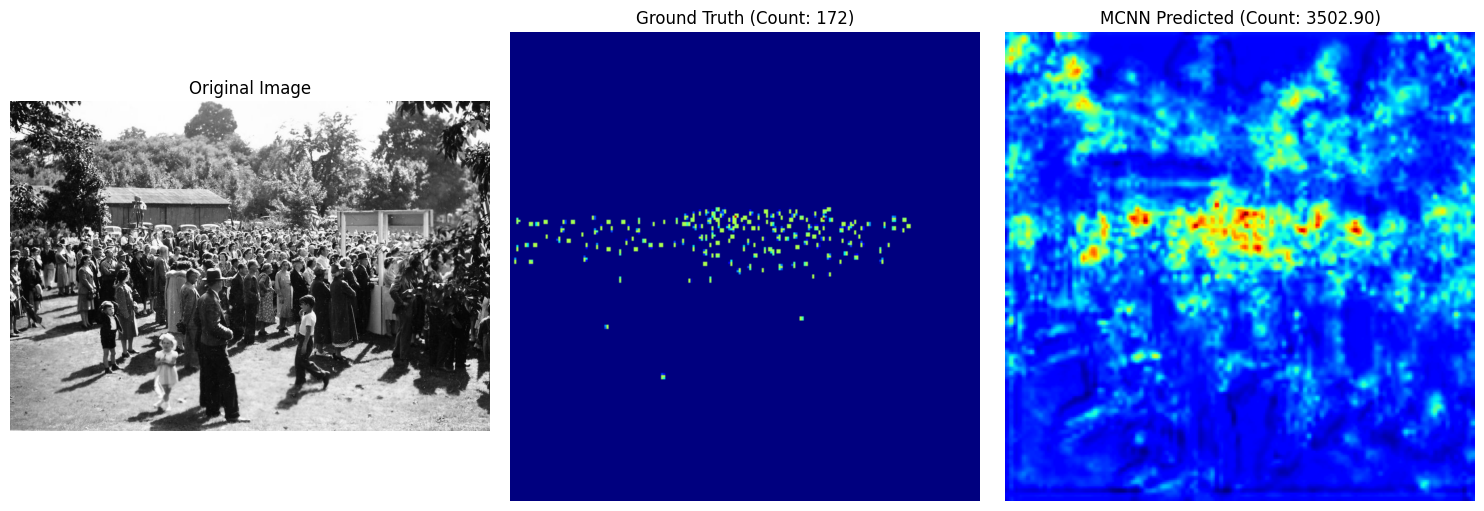

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


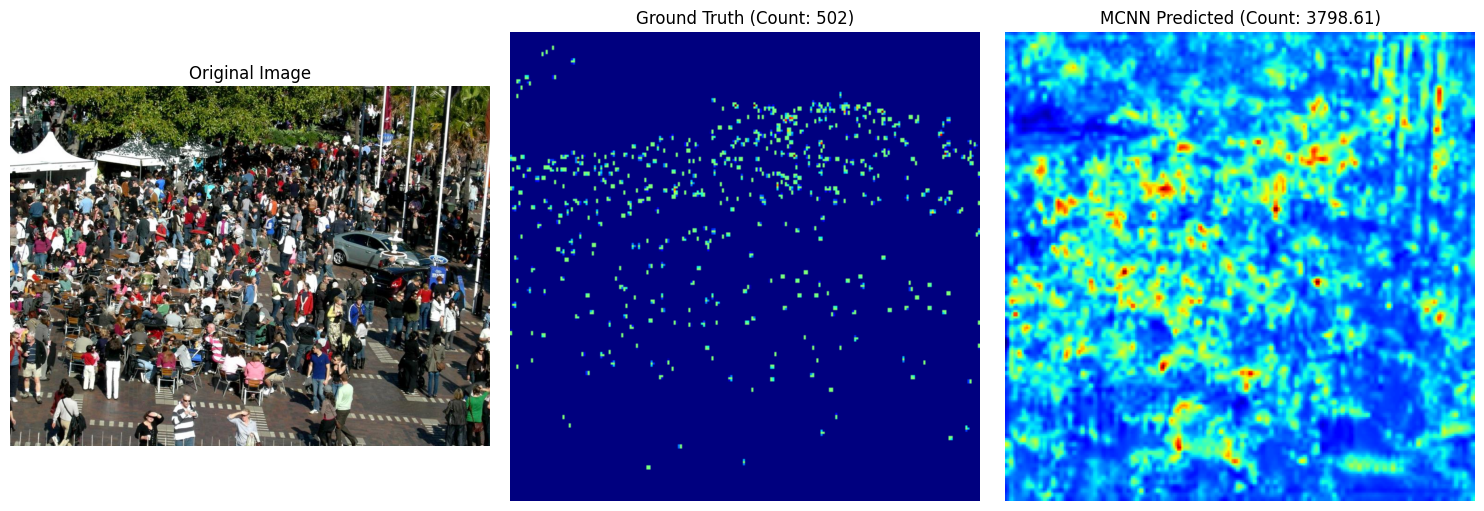

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


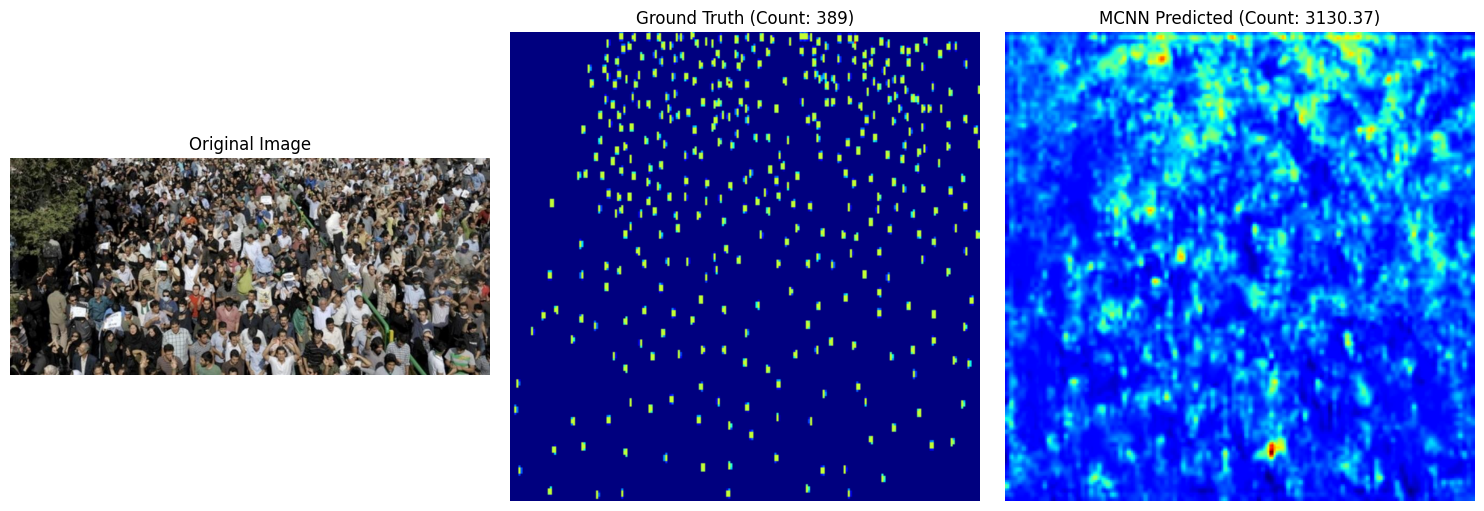

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


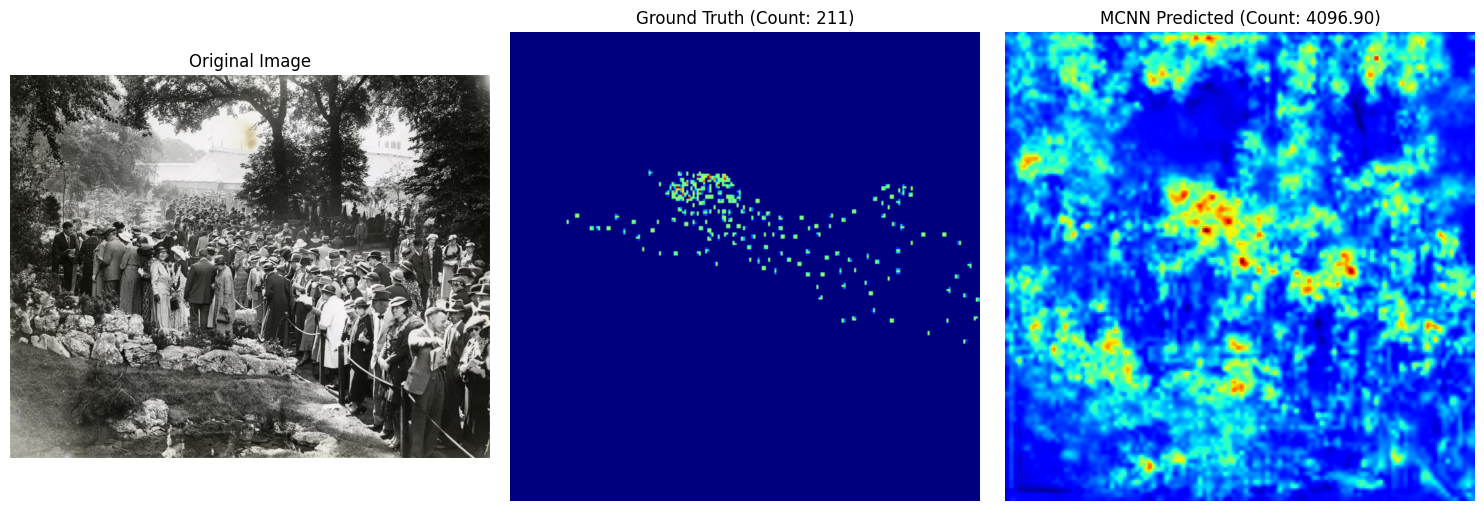

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


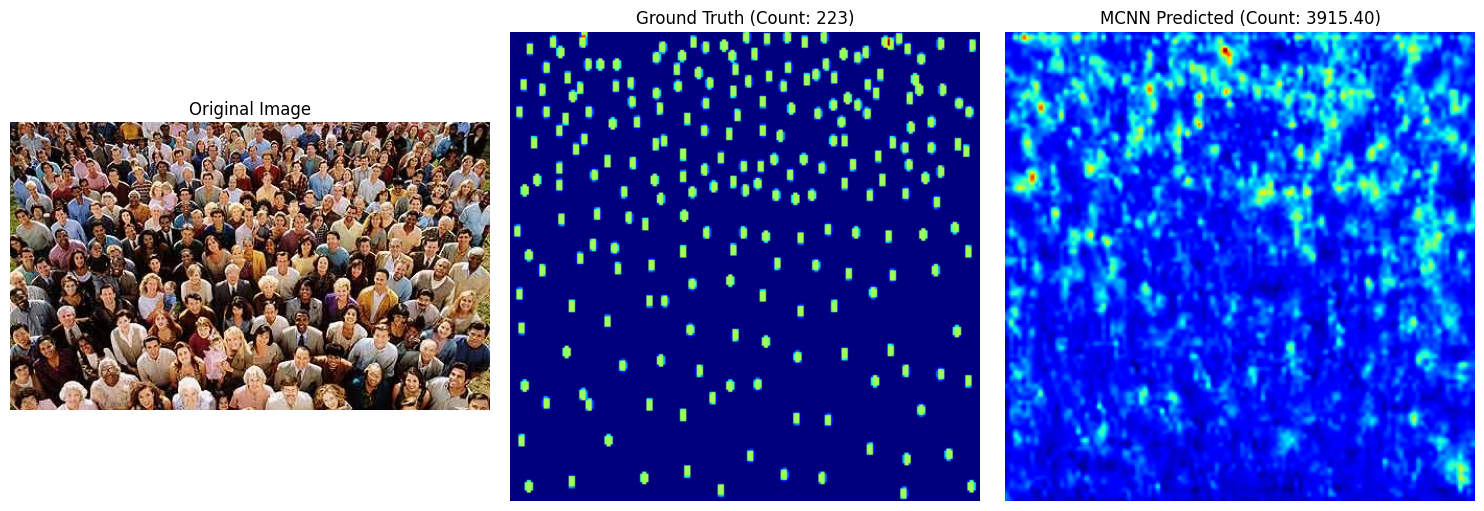

In [ ]:
for sample_index in range(5):
    visualize_result(test_images[sample_index], test_gt[sample_index], model)
